In [1]:
import warnings
import time

import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines
from lifelines.utils import concordance_index

import os

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

from scipy.stats import norm, t, probplot, pearsonr, rankdata
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

# import thetaflow as thf
import modelnn2 as thf

2026-03-22 14:19:13.005317: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774199953.111909   15685 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774199953.142338   15685 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774199953.386158   15685 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774199953.386182   15685 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774199953.386184   15685 computation_placer.cc:177] computation placer alr

In this notebook, we attempt to use thetaflow to replicate the exact structure used in Cox-nnet. An implementation for the Cox model, where the inputs are actually the outputs of a dense neural network.

In [2]:
# Count DSeq2 transformed matrix passed to the vsd in R
df_coxnnet_kirc = pd.read_csv("log_counts_kirc.csv", header = None)

# times = pd.read_csv("ytime_coxnnet.csv", header = None).iloc[:,0].to_numpy()
# delta = pd.read_csv("ystatus_coxnnet.csv", header = None).iloc[:,0].to_numpy()

print("Data dimensions: {}".format(df_coxnnet_kirc.shape))
df_coxnnet_kirc.head()

Data dimensions: (517, 19500)


,0,1,2,3,4,5,6,7,8,9,...,19490,19491,19492,19493,19494,19495,19496,19497,19498,19499
0,-0.591395,0.672267,-1.019161,-1.672059,-0.479418,-1.040106,-0.11062,-1.204243,-1.084686,0.228324,...,-1.702740,-1.906983,-2.164082,0.328562,-1.940324,-0.843944,-1.472628,-1.760932,-0.402279,-0.344267
1,-0.591395,-1.179125,-1.582692,0.838075,-0.022309,0.525567,-0.11062,-0.108385,0.317944,-0.645397,...,-0.939731,-1.561306,-0.548214,-1.148819,-0.818804,-0.864956,-0.017958,0.033100,1.349957,-0.344267
2,-0.437130,0.518018,-0.778402,-1.023351,-0.169857,0.935554,-0.11062,-0.108385,-1.084686,1.201025,...,0.152828,-0.173846,-1.775287,-1.333401,-0.400217,-1.309979,-0.668346,0.180228,-0.994432,-0.344267
3,-0.773851,-0.217862,0.078533,-0.963403,-0.079721,1.253564,-0.11062,0.583024,0.317944,0.643141,...,-0.087866,0.074576,-0.073961,0.000807,-0.179123,-0.147044,-0.533847,-0.203854,-0.144667,-0.344267
4,0.325574,-0.712502,-0.024271,-0.262327,0.978589,0.525567,-0.11062,0.987472,4.204973,-0.468218,...,-0.048902,-0.206010,0.614476,-1.333401,-0.082739,0.265071,0.438234,0.286619,-1.049497,-0.344267


In [3]:
df_log = pd.read_csv("tcga_brca_count_data_coxnnet.csv")
df = pd.read_csv("tcga_brca_count_data.csv")

X = df.iloc[:,2:]
X_log = df_log.iloc[:,2:]
X_coxnnet = df_coxnnet_kirc

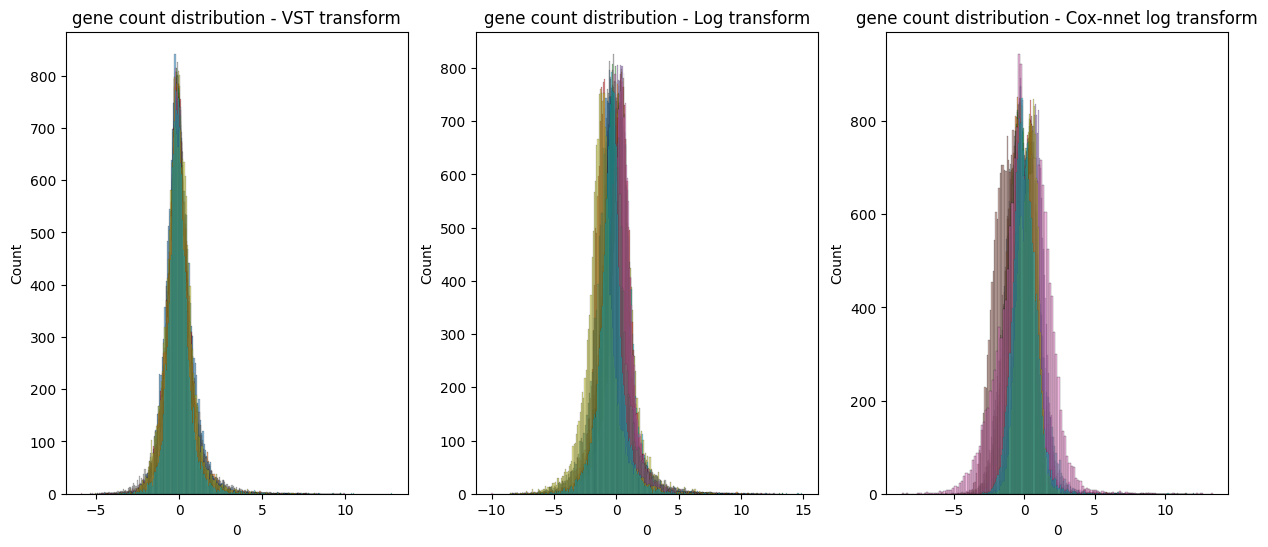

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (15,6))

for i in range(20):
    sns.histplot(X.iloc[i, :], ax = ax[0], alpha = 0.5)
    sns.histplot(X_log.iloc[i, :], ax = ax[1], alpha = 0.5)
    sns.histplot(X_coxnnet.iloc[i, :], ax = ax[2], alpha = 0.5)

ax[0].set_title("gene count distribution - VST transform")
ax[1].set_title("gene count distribution - Log transform")
ax[2].set_title("gene count distribution - Cox-nnet log transform")
plt.show()

Note that above we load two preprocessed datasets from the TCGA-BRCA database and one from the TCGA-KIRC database. The latter is the exact same dataset considered in the cox-nnet original paper. Here, we only load it to show the differences between the different preprocessing approaches. Certainly, the first one seems to be the most modern, with a Variance Stabilization Transform follower my a mean scaling. The second consists in simply taking the $log(x+1)$ where $x$ stands for the gene-count matrix. The last one is not much clear, but it consists of a similar processing than the second, according to the paper. We can see by the scales that both methods indeed appear to vary similarly.

We will be considering for the analysis in this dataset only the first dataset from the TCGA-BRCA database.

In [59]:
gene_metadata["gene_id"]

0        ENSG00000000003.15
1         ENSG00000000005.6
2        ENSG00000000419.13
3        ENSG00000000457.14
4        ENSG00000000460.17
                ...        
19957     ENSG00000288661.1
19958     ENSG00000288669.1
19959     ENSG00000288671.1
19960     ENSG00000288674.1
19961     ENSG00000288675.1
Name: gene_id, Length: 19962, dtype: object

In [61]:
gene_metadata["gene_name"]

0            TSPAN6
1              TNMD
2              DPM1
3             SCYL3
4          C1orf112
            ...    
19957    AL451106.1
19958    AC008763.4
19959    AC006486.3
19960    AL391628.1
19961    AP006621.6
Name: gene_name, Length: 19962, dtype: object

In [65]:
gene_metadata = pd.read_csv("gene_metadata.csv")

gene_id_to_name = {gene_metadata["gene_id"].iloc[i]: gene_metadata["gene_name"].iloc[i] for i in range(gene_metadata.shape[0])}

gene_metadata.head()

,source,type,score,phase,gene_id,gene_type,gene_name,level,hgnc_id,havana_gene
0,HAVANA,gene,NaN,NaN,ENSG00000000003.15,protein_coding,TSPAN6,2,HGNC:11858,OTTHUMG00000022002.2
1,HAVANA,gene,NaN,NaN,ENSG00000000005.6,protein_coding,TNMD,2,HGNC:17757,OTTHUMG00000022001.2
2,HAVANA,gene,NaN,NaN,ENSG00000000419.13,protein_coding,DPM1,2,HGNC:3005,OTTHUMG00000032742.2
3,HAVANA,gene,NaN,NaN,ENSG00000000457.14,protein_coding,SCYL3,2,HGNC:19285,OTTHUMG00000035941.6
4,HAVANA,gene,NaN,NaN,ENSG00000000460.17,protein_coding,C1orf112,2,HGNC:25565,OTTHUMG00000035821.9


In [5]:
X = df.iloc[:,2:]

y = df["time"].to_numpy()/365
delta = df["delta"].to_numpy()
data = [tf.constant(y, shape = (len(y), 1), dtype = tf.float32), tf.constant(delta, shape = (len(delta), 1), dtype = tf.float32)]

In [6]:
X_train, X_test, y_train, y_test, delta_train, delta_test = train_test_split(X, y, delta, test_size = 0.2, random_state = 10)

X_train = tf.cast(X_train, dtype = tf.float32)
X_test = tf.cast(X_test, dtype = tf.float32)
data_train = [tf.constant(y_train, shape = (len(y_train), 1), dtype = tf.float32), tf.constant(delta_train, shape = (len(delta_train), 1), dtype = tf.float32)]
data_test = [tf.constant(y_test, shape = (len(y_test), 1), dtype = tf.float32), tf.constant(delta_test, shape = (len(delta_test), 1), dtype = tf.float32)]

2026-03-22 14:19:46.961914: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 117970496 exceeds 10% of free system memory.
2026-03-22 14:19:47.068442: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29630440 exceeds 10% of free system memory.


In [7]:
def build_cox_nnet(dropout_rate = 0.1, ridge_penalty = 1.0e-2):
    cox_nnet_parameters = {
        "theta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": 0.0},
    }
    
    def partial_loglikelihood_loss(model, nn_output, data):
        # Unpack your data tuple
        X, y, delta = data
        theta = model.get_variable("theta", nn_output)
        
        # Shapes for broascasting
        y_col = tf.reshape(y, [-1, 1])
        y_row = tf.reshape(y, [1, -1])
        theta_col = tf.reshape(theta, [-1, 1])
        delta_col = tf.reshape(delta, [-1, 1])

        # Matrix form to replace the sum loop in the partial log-likelihoood
        R_matrix = tf.cast(y_row >= y_col, dtype = tf.float32)
        exp_theta = tf.math.exp(theta_col)
        risk_sum = tf.matmul(R_matrix, exp_theta)
        log_risk_sum = tf.math.log(risk_sum + 1e-7)
        
        pll = tf.reduce_sum( delta_col * (theta_col - log_risk_sum) )
        return -pll

    def neural_network(model, seed = None):
        initializer = initializers.GlorotNormal(seed = seed)
        ridge = tf.keras.regularizers.L2(l2 = ridge_penalty)
        
        # 1. The Hidden Layer (Feature Extractor)
        model.dense1 = layers.Dense(
            units = 132,
            activation = "tanh",     
            kernel_initializer = initializer,
            kernel_regularizer = ridge,
            use_bias = True,
            dtype = tf.float32, 
            name = "latent_representation"
        )
        
        # 2. The Dropout Layer
        model.dropout = layers.Dropout(rate = dropout_rate, seed = seed)
        
        # 3. The Cox Beta Layer (The brilliant realization)
        model.output_layer = layers.Dense(
            units = 1, 
            activation = None,
            use_bias = False,
            kernel_initializer = initializer,
            kernel_regularizer = ridge,
            dtype = tf.float32,
            name = "beta_coefficients"
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dropout(x, training = training)
        return model.output_layer(x) # Returns the final theta scalar for each patient
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        return x
    
    return cox_nnet_parameters, partial_loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [8]:
def train_eval_cox_nnet(X_train, data_train, cox_nnet_parameters, 
                        cox_nnet_partial_loglikelihood_loss, cox_nnet_neural_network, cox_nnet_network_call, cox_nnet_network_call_nolast,
                        epochs = 10000, shuffle = True, metrics_update_freq = 50,
                        fine_tune = False,
                        get_covariances = False,
                        validation = False, val_prop = 0.2,
                        optimizer_nn = optimizers.SGD(learning_rate = 0.1, momentum = 0.9, nesterov = True, clipnorm = 1.0),
                        train_batch_size = None, val_batch_size = None,
                        buffer_size = 4096, gradient_accumulation_steps = None,
                        early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 500,
                        reduce_lr = True, reduce_lr_warmup = 10,
                        reduce_lr_factor = 0.9, reduce_lr_min_delta = 1.0e-4, reduce_lr_patience = 5,
                        reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
                        deterministic = True,
                        verbose = 1, print_freq = 50):
    """
        Get data and configuration and trains a completely new cox-nnet model and returns it.
    """
    cox_nnet_model = thf.ModelNN(cox_nnet_parameters, cox_nnet_partial_loglikelihood_loss,
                                 cox_nnet_neural_network, cox_nnet_network_call,
                                 cox_nnet_network_call_nolast, input_dim = (None, X_train.shape[1]), seed = 10)
    cox_nnet_model.pre_train_model(X_train, data_train,
                                   epochs = 1000, shuffle = True,
                                   optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                   verbose = 1, track_time = True)
    cox_nnet_model.train_model(X_train, data_train,
                               epochs = epochs, shuffle = shuffle, metrics_update_freq = metrics_update_freq,
                               fine_tune = fine_tune,
                               get_covariances = get_covariances,
                               validation = validation, val_prop = val_prop,
                               optimizer_nn = optimizer_nn,
                               train_batch_size = train_batch_size, val_batch_size = val_batch_size,
                               buffer_size = buffer_size, gradient_accumulation_steps = gradient_accumulation_steps,
                               early_stopping = early_stopping, early_stopping_tolerance = early_stopping_tolerance, early_stopping_warmup = early_stopping_warmup,
                               reduce_lr = reduce_lr, reduce_lr_warmup = reduce_lr_warmup,
                               reduce_lr_factor = reduce_lr_factor, reduce_lr_min_delta = reduce_lr_min_delta, reduce_lr_patience = reduce_lr_patience,
                               reduce_lr_cooldown = reduce_lr_cooldown, reduce_lr_min_lr = reduce_lr_min_lr,
                               deterministic = deterministic,
                               verbose = verbose, print_freq = print_freq)
    return cox_nnet_model

In [9]:
cox_nnet_parameters, \
cox_nnet_partial_loglikelihood_loss, \
cox_nnet_neural_network, \
cox_nnet_network_call, \
cox_nnet_network_call_nolast = build_cox_nnet(dropout_rate = 0.1, ridge_penalty = 1.0e-2)

with tf.device("/GPU:0"):
    model_nesterov = train_eval_cox_nnet(X_train, data_train, cox_nnet_parameters,
                                        cox_nnet_partial_loglikelihood_loss, cox_nnet_neural_network, cox_nnet_network_call, cox_nnet_network_call_nolast,
                                        optimizer_nn = optimizers.SGD(learning_rate = 0.1, momentum = 0.9, nesterov = True, clipnorm = 1.0),
                                        verbose = True)
    model_rmsprop = train_eval_cox_nnet(X_train, data_train, cox_nnet_parameters, 
                                       cox_nnet_partial_loglikelihood_loss, cox_nnet_neural_network, cox_nnet_network_call, cox_nnet_network_call_nolast,
                                       optimizer_nn = optimizers.RMSprop(learning_rate = 0.01, clipnorm = 1.0),
                                       verbose = True)
    model_adam = train_eval_cox_nnet(X_train, data_train, cox_nnet_parameters, 
                                    cox_nnet_partial_loglikelihood_loss, cox_nnet_neural_network, cox_nnet_network_call, cox_nnet_network_call_nolast,
                                    optimizer_nn = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                                    verbose = True)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Optimizing... Epoch: [ 700 / 1000 ]  | Loss:  1.24938317e-08 | Param Dist:  0.000163805569 | Independent Learning rate:  0.001 | Network Learning rate:  0.1 | [Speed tracking disabled for determinism]   
Stopping. Model has converged at epoch 800
Optimizing... Epoch: [ 800 / 1000 ]  | Loss:  4.09713305e-11 | Param Dist:  6.63766832e-06 | Independent Learning rate:  0.001 | Network Learning rate:  0.1 | [Speed tracking disabled for determinism]   GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 9950 / 10000 ]  | Loss:  295.911774 | Param Dist:  1.19186604 | Independent Learning rate:  0.001 | Network Learning rate:  0.0531440899 | [Speed tracking disabled for determinism]    
Done.
Optimization finished in 107.506 seconds.

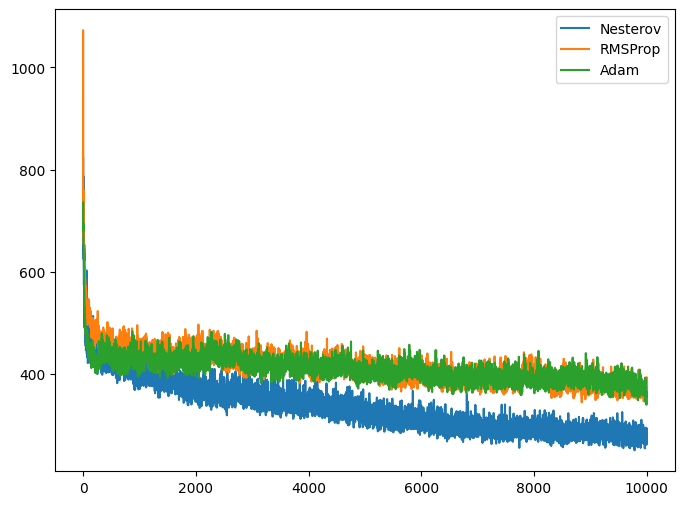

In [10]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

ax.plot(np.arange( model_nesterov.last_epoch+1 ), model_nesterov.loss_history.numpy(), label = "Nesterov")
ax.plot(np.arange( model_rmsprop.last_epoch+1 ), model_rmsprop.loss_history.numpy(), label = "RMSProp")
ax.plot(np.arange( model_adam.last_epoch+1 ), model_adam.loss_history.numpy(), label = "Adam")
ax.legend()

plt.show()

We can see that the SGD with Nesterov optimization performed better than the RMSProp and Adam proposals.

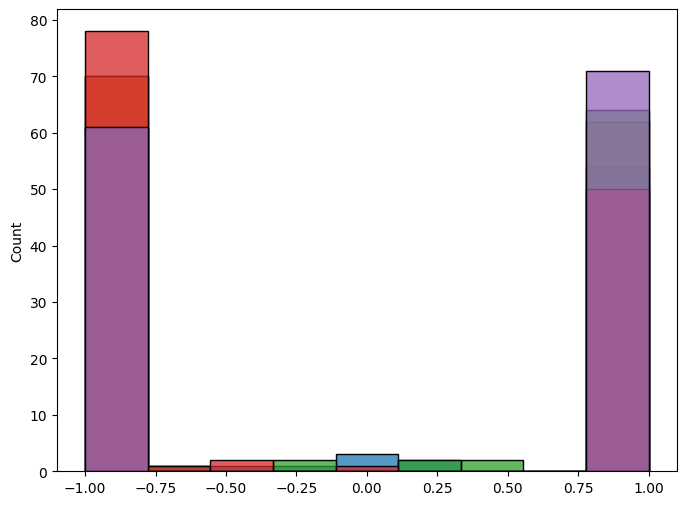

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

hidden_activations = cox_nnet_network_call_nolast(model_nesterov, X).numpy()
# Plot the hidden layer weights histogram for each of the first 5 patients
for i in range(5):
    sns.histplot(hidden_activations[i, :], ax = ax)

In the plot above, we can see the histograms for the activation values in the hidden layer for the first 5 patients in the dataset. Since the activation function is tanh, we can see that most of the network outputs saturate in 1 and -1 depending on the sign of that neuron's contribution to the final model.

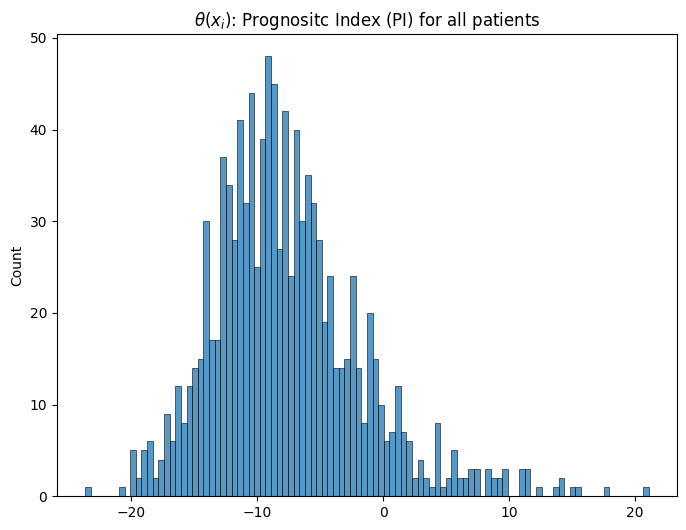

In [12]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.histplot(x = model_nesterov.predict(X)["theta"].numpy().flatten(), bins = 100, ax = ax)
ax.set_title(r"$\theta(x_i)$: Prognositc Index (PI) for all patients")
plt.show()

In [13]:
theta_predictions = model_nesterov.predict(X_test)["theta"].numpy().flatten()

time_true = y_test
event_true = delta_test

c_index = concordance_index(
    event_times = time_true, 
    predicted_scores = -theta_predictions,
    event_observed = event_true
)

print(f"Harrell's C-index: {c_index:.4f}")

Harrell's C-index: 0.7390


As we can see above, the model is able to generalize quite well the predictions for a test set. Indeed, we obtained a C-index of around 0.73, suggesting that the model was able to discrminate patients lifetimes given their genomic expression profiles.

Before we can properly get the optimal hyperparameters, we will consider a longer training to check when does the model loss actually reaches a plateau. For that we will use the faster tested optimizer, which is the Nesterov SGD.

In [14]:
with tf.device("/GPU:0"):
    model_nesterov_longrun = train_eval_cox_nnet(X_train, data_train, cox_nnet_parameters,
                                                 cox_nnet_partial_loglikelihood_loss, cox_nnet_neural_network, cox_nnet_network_call, cox_nnet_network_call_nolast,
                                                 optimizer_nn = optimizers.SGD(learning_rate = 0.1, momentum = 0.9, nesterov = True, clipnorm = 1.0),
                                                 epochs = 25000, early_stopping_warmup = 1000,
                                                 verbose = True)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Optimizing... Epoch: [ 700 / 1000 ]  | Loss:  1.24938317e-08 | Param Dist:  0.000163805569 | Independent Learning rate:  0.001 | Network Learning rate:  0.1 | [Speed tracking disabled for determinism]   
Stopping. Model has converged at epoch 800
Optimizing... Epoch: [ 800 / 1000 ]  | Loss:  4.09713305e-11 | Param Dist:  6.63766832e-06 | Independent Learning rate:  0.001 | Network Learning rate:  0.1 | [Speed tracking disabled for determinism]   GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 20550 / 25000 ]  | Loss:  236.079483 | Param Dist:  0.685646057 | Independent Learning rate:  0.001 | Network Learning rate:  0.0228767805 | [Speed tracking disabled for determinism]   
Stopping. Model has converged at epoch 20600
O

/tmp/ipykernel_4862/4139478568.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


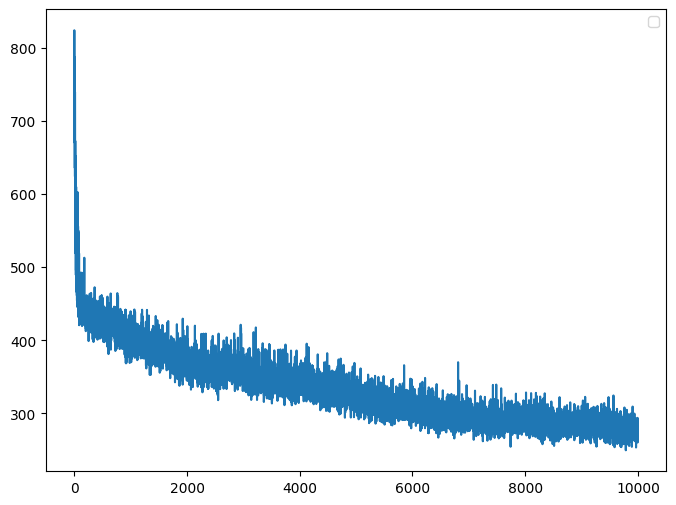

In [15]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

ax.plot(np.arange( model_nesterov.last_epoch+1 ), model_nesterov.loss_history.numpy())
ax.legend()

plt.show()

/home/natan/.pyenv/versions/3.10.17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


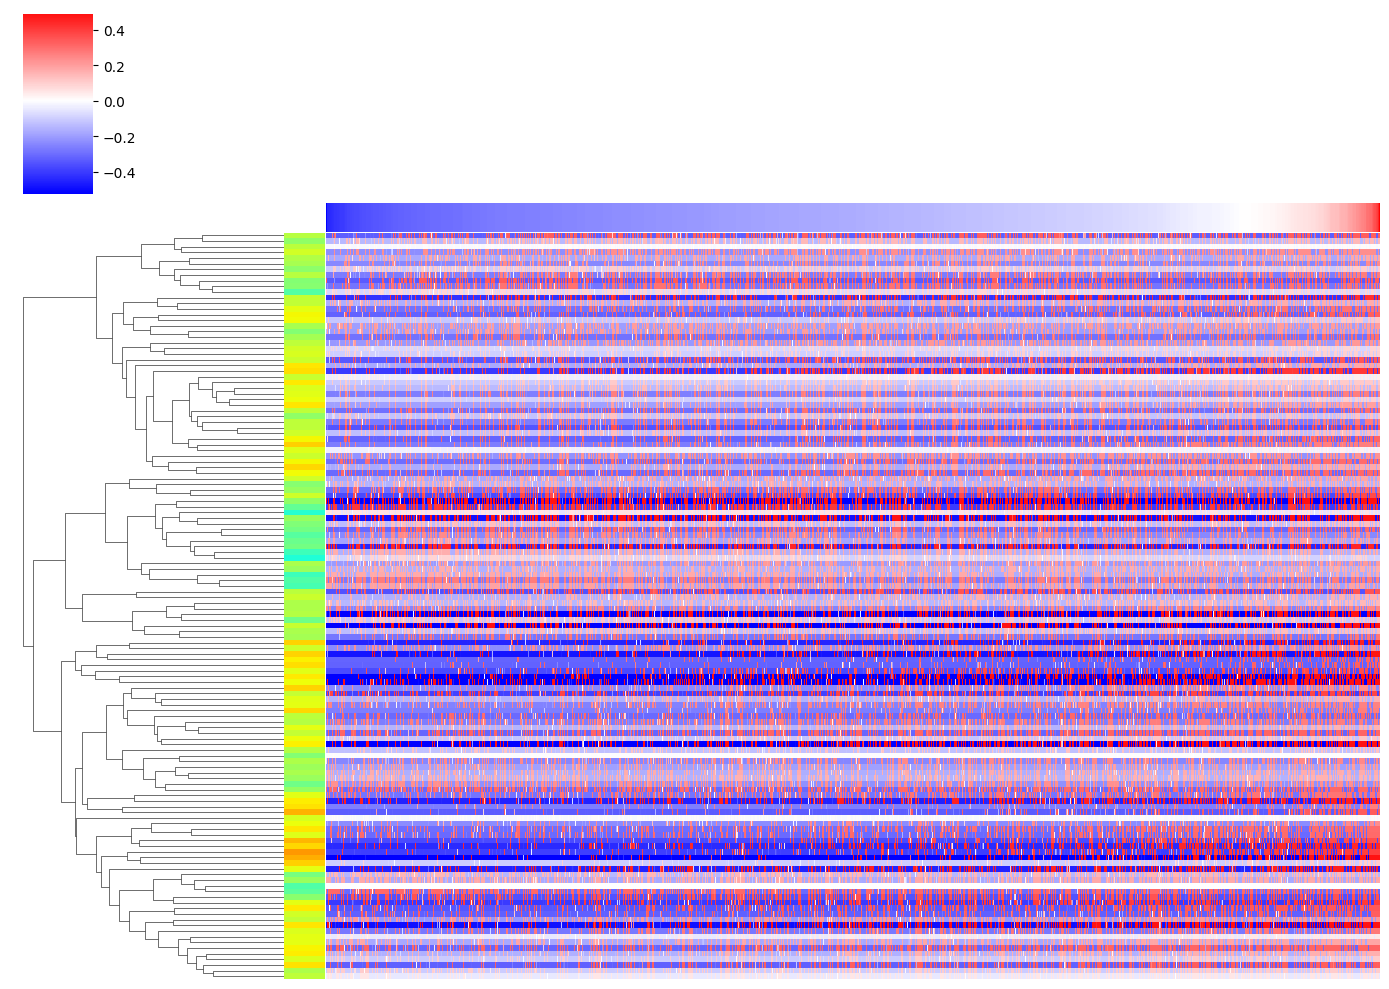

In [16]:
hidden_activations = cox_nnet_network_call_nolast(model_nesterov, X).numpy()
beta_weights = model_nesterov.output_layer.get_weights()[0].flatten()
theta_predictions = model_nesterov.predict(X)["theta"].numpy().flatten()

# Node Contributions (Weighted Activations)
contributions = hidden_activations * beta_weights 

# Sort Patients by Prognostic-Index (Theta)
patient_sort_idx = np.argsort(theta_predictions, axis = 0)
sorted_theta = theta_predictions[patient_sort_idx]
sorted_contributions = contributions[patient_sort_idx, :] 

# 4. Calculate the Pearson Correlation between each node's contribution and the PI
node_correlations = []
for k in range( len(beta_weights) ):
    corr, _ = pearsonr(contributions[:, k], theta_predictions)
    node_correlations.append(corr)
node_correlations = np.array(node_correlations)

# 5. Prepare DataFrames for Seaborn
# We transpose the matrix so Nodes are Rows (55) and Patients are Columns (N)
df_plot = pd.DataFrame(sorted_contributions.T)

# 6. Create Color Annotations for the Axes
# Create the top bar (Patient PI): Blue for low risk, Red for high risk
pi_norm = mcolors.Normalize(vmin = sorted_theta.min(), vmax = sorted_theta.max())
pi_cmap = plt.get_cmap('bwr')
col_colors = [pi_cmap(pi_norm(val)) for val in sorted_theta]

# Create the side bar (Node Correlation): Blue for negative, Red for positive correlation
corr_norm = mcolors.Normalize(vmin=-1, vmax=1)
corr_cmap = plt.get_cmap('jet') # The paper uses a rainbow-like colormap here
row_colors = [corr_cmap(corr_norm(val)) for val in node_correlations]

g = sns.clustermap(
    df_plot,
    cmap = "bwr",
    metric = "correlation",
    row_cluster = True,
    col_cluster = False,
    row_colors = row_colors,
    col_colors = col_colors,
    figsize = (14, 10),
    xticklabels = False,
    yticklabels = False,
    center = 0,
    robust = True
)

plt.show()

# Obtaining the optimal hyperparameters

In order to find the best dropout rates and the best ridge hyperparameter, we will perform a gridsearch with cross validation. Since this process is computationally heavy, we will not consider a very large grid.

In [17]:
from sklearn.model_selection import KFold
import itertools
import subprocess
import pickle

In [18]:
def call_grid_search_cox_nnet(X, y, delta, param_grid, n_splits = 5, epochs = 10000):
    # 1. Generate all combinations of hyperparameters
    keys = param_grid.keys()
    values = param_grid.values()
    param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    best_c_index = -np.inf
    best_params = None
    all_results = []

    print(f"Starting Grid Search: {len(param_combinations)} combinations.")
    print("-" * 50)

    # 2. Iterate over the combinations in the main process
    for params in param_combinations:
        print(f"Testing Parameters: {params}")
        
        # Pack the payload for THIS SPECIFIC combination
        payload = {
            "X": X,
            "y": y,
            "delta": delta,
            "params": params,       # Sending only one dictionary
            "n_splits": n_splits,
            "epochs": epochs
        }
        
        # Save payload to disk
        with open("grid_search_payload.pkl", "wb") as f:
            pickle.dump(payload, f)
            
        # Run the n_folds in a subprocess that will die upon finishing, freeing all the used VRAM In the process
        subprocess.run(["python3", "Kfold_cox_nnet.py"],
                       stdout = subprocess.DEVNULL,
                       stderr = subprocess.DEVNULL)

        # 4. Read the results back from the dead subprocess
        with open("grid_search_results.pkl", "rb") as f:
            result_data = pickle.load(f)
            
        avg_c_index = result_data["avg_c_index"]
        fold_c_indices = result_data["fold_c_indices"]
        
        print(f"-> Average C-index: {avg_c_index:.4f} | Folds: {[round(x, 4) for x in fold_c_indices]}\n")
        
        all_results.append({
            'params': params, 
            'avg_c_index': avg_c_index, 
            'fold_c_indices': fold_c_indices
        })
        
        # 5. Update the best configuration tracker
        if avg_c_index > best_c_index:
            best_c_index = avg_c_index
            best_params = params

    print("-" * 50)
    print(f"Best Parameters: {best_params}")
    print(f"Best Average C-index: {best_c_index:.4f}")
    
    return best_params, all_results

In [20]:
start = time.perf_counter()
param_grid = {
    'dropout_rate': [0.0, 0.1, 0.2, 0.3],
    'ridge_penalty': [1e-1, 1e-2, 1e-3, 1e-4]
}

# --- Example Execution ---
best_params, all_results = call_grid_search_cox_nnet(X, y, delta, param_grid, n_splits = 5, epochs = 25000)
elapsed = time.perf_counter() - start
print("Execution time:", elapsed)

print("best_params:", best_params)

Starting Grid Search: 16 combinations.
--------------------------------------------------
Testing Parameters: {'dropout_rate': 0.0, 'ridge_penalty': 0.1}
-> Average C-index: 0.6959 | Folds: [np.float64(0.6465), np.float64(0.6649), np.float64(0.6614), np.float64(0.757), np.float64(0.7497)]

Testing Parameters: {'dropout_rate': 0.0, 'ridge_penalty': 0.01}
-> Average C-index: 0.5796 | Folds: [np.float64(0.6245), np.float64(0.4814), np.float64(0.6249), np.float64(0.6179), np.float64(0.5495)]

Testing Parameters: {'dropout_rate': 0.0, 'ridge_penalty': 0.001}
-> Average C-index: 0.5804 | Folds: [np.float64(0.4702), np.float64(0.5658), np.float64(0.6372), np.float64(0.6219), np.float64(0.6067)]

Testing Parameters: {'dropout_rate': 0.0, 'ridge_penalty': 0.0001}
-> Average C-index: 0.5932 | Folds: [np.float64(0.577), np.float64(0.5735), np.float64(0.5844), np.float64(0.6584), np.float64(0.5726)]

Testing Parameters: {'dropout_rate': 0.1, 'ridge_penalty': 0.1}
-> Average C-index: 0.6991 | Folds

In [22]:
import json
with open("best_params.json", "w") as args_file:
    json.dump(best_params, args_file)
with open("all_results.json", "w") as args_file:
    json.dump(all_results, args_file)

Now that we selected the optimal dropout_rate and the optimal ridge penalty for our given configurations, we can proceed using that model to take conclusions about which genes were learned as the most influential and if we can capture any known results in the literature.

In [9]:
X = df.iloc[:,2:]

y = df["time"].to_numpy()/365
delta = df["delta"].to_numpy()
data = [tf.constant(y, shape = (len(y), 1), dtype = tf.float32), tf.constant(delta, shape = (len(delta), 1), dtype = tf.float32)]

In [10]:
with tf.device("/GPU:0"):
    cox_nnet_parameters, \
    cox_nnet_partial_loglikelihood_loss, \
    cox_nnet_neural_network, \
    cox_nnet_network_call, \
    cox_nnet_network_call_nolast = build_cox_nnet(dropout_rate = 0.1, ridge_penalty = 1.0e-3)
    model_nesterov = train_eval_cox_nnet(X, data, cox_nnet_parameters,
                                         cox_nnet_partial_loglikelihood_loss, cox_nnet_neural_network, cox_nnet_network_call, cox_nnet_network_call_nolast,
                                         get_covariances = True,
                                         optimizer_nn = optimizers.SGD(learning_rate = 0.1, momentum = 0.9, nesterov = True, clipnorm = 1.0),
                                         epochs = 25000, early_stopping_warmup = 1000,
                                         deterministic = True,
                                         verbose = True)

2026-03-22 14:19:55.506063: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 147600936 exceeds 10% of free system memory.
2026-03-22 14:19:55.668831: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 73800468 exceeds 10% of free system memory.


GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Optimizing... Epoch: [ 600 / 1000 ]  | Loss:  9.54463076e-07 | Param Dist:  0.000829717785 | Independent Learning rate:  0.001 | Network Learning rate:  0.1 | [Speed tracking disabled for determinism]   
Stopping. Model has converged at epoch 700
Optimizing... Epoch: [ 700 / 1000 ]  | Loss:  3.06487236e-09 | Param Dist:  6.92691538e-05 | Independent Learning rate:  0.001 | Network Learning rate:  0.1 | [Speed tracking disabled for determinism]   

2026-03-22 14:20:11.743473: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 147600936 exceeds 10% of free system memory.


GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 19950 / 25000 ]  | Loss:  365.466827 | Param Dist:  1.57625139 | Independent Learning rate:  0.001 | Network Learning rate:  0.0313810483 | [Speed tracking disabled for determinism]    
Stopping. Model has converged at epoch 20000
Optimizing... Epoch: [ 20000 / 25000 ]  | Loss:  340.283447 | Param Dist:  1.57542789 | Independent Learning rate:  0.001 | Network Learning rate:  0.0313810483 | [Speed tracking disabled for determinism]   
Done.
Extracting covariance structure.
Done.
Optimization finished in 232.026 seconds.


I0000 00:00:1774200244.405753   15685 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x5c5895436ac0


/home/natan/.pyenv/versions/3.10.17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


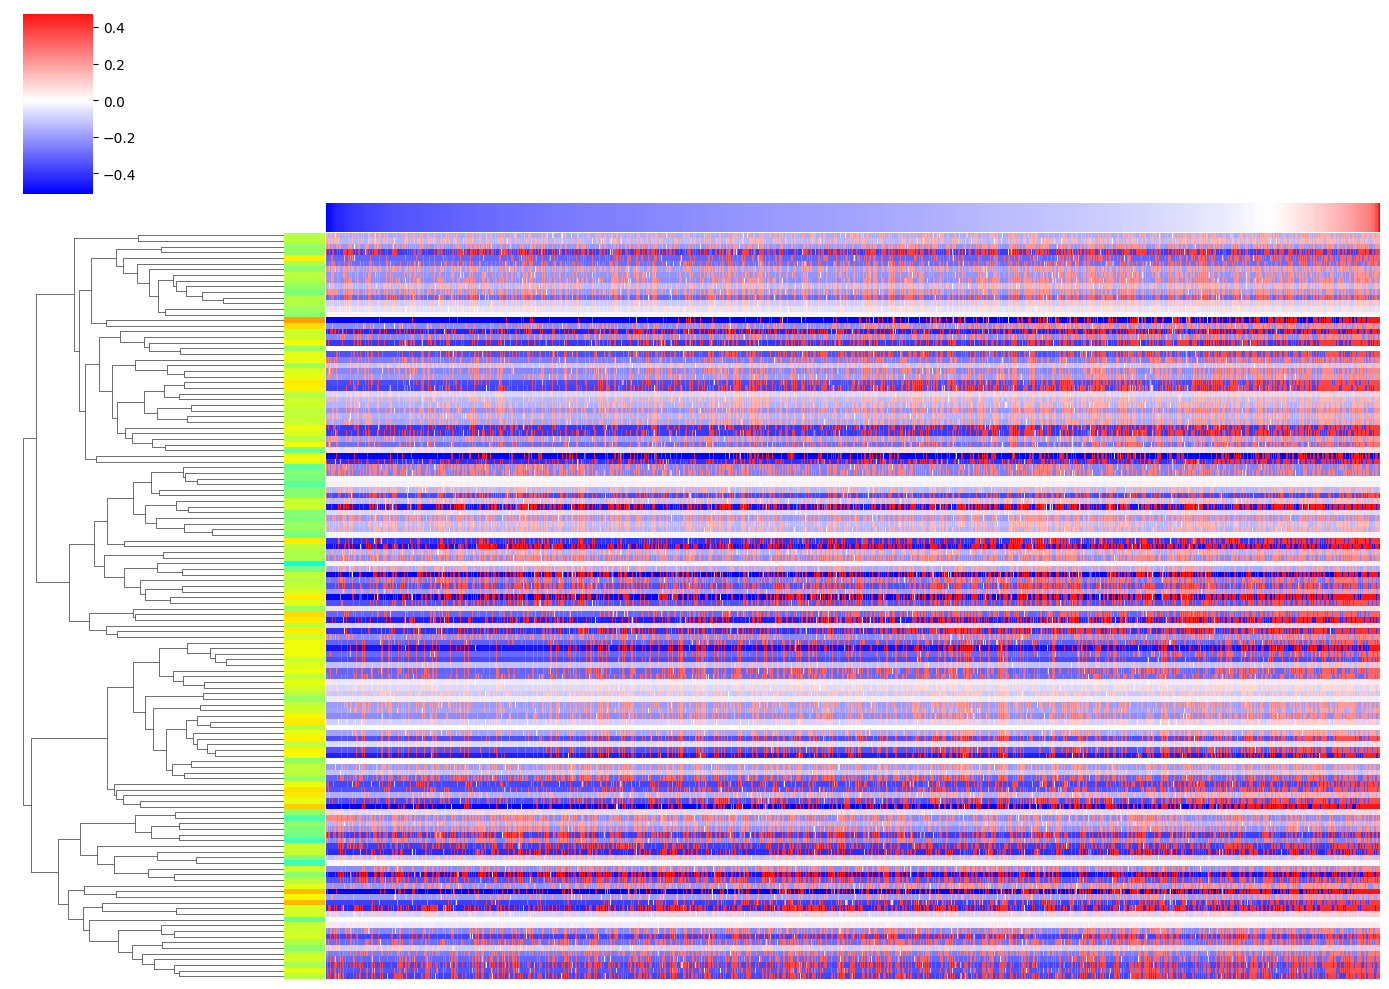

In [11]:
hidden_activations = cox_nnet_network_call_nolast(model_nesterov, X).numpy()
beta_weights = model_nesterov.output_layer.get_weights()[0].flatten()
theta_predictions = model_nesterov.predict(X)["theta"].numpy().flatten()

# Node Contributions (Weighted Activations)
contributions = hidden_activations * beta_weights 

# Sort Patients by Prognostic-Index (Theta)
patient_sort_idx = np.argsort(theta_predictions, axis = 0)
sorted_theta = theta_predictions[patient_sort_idx]
sorted_contributions = contributions[patient_sort_idx, :] 

# 4. Calculate the Pearson Correlation between each node's contribution and the PI
node_correlations = []
for k in range( len(beta_weights) ):
    corr, _ = pearsonr(contributions[:, k], theta_predictions)
    node_correlations.append(corr)
node_correlations = np.array(node_correlations)

# 5. Prepare DataFrames for Seaborn
# We transpose the matrix so Nodes are Rows (55) and Patients are Columns (N)
df_plot = pd.DataFrame(sorted_contributions.T)

# 6. Create Color Annotations for the Axes
# Create the top bar (Patient PI): Blue for low risk, Red for high risk
pi_norm = mcolors.Normalize(vmin = sorted_theta.min(), vmax = sorted_theta.max())
pi_cmap = plt.get_cmap('bwr')
col_colors = [pi_cmap(pi_norm(val)) for val in sorted_theta]

# Create the side bar (Node Correlation): Blue for negative, Red for positive correlation
corr_norm = mcolors.Normalize(vmin=-1, vmax=1)
corr_cmap = plt.get_cmap('jet') # The paper uses a rainbow-like colormap here
row_colors = [corr_cmap(corr_norm(val)) for val in node_correlations]

g = sns.clustermap(
    df_plot,
    cmap = "bwr",
    metric = "correlation",
    row_cluster = True,
    col_cluster = False,
    row_colors = row_colors,
    col_colors = col_colors,
    figsize = (14, 10),
    xticklabels = False,
    yticklabels = False,
    center = 0,
    robust = True
)

plt.show()

In [12]:
from scipy.stats import norm, t, probplot, pearsonr

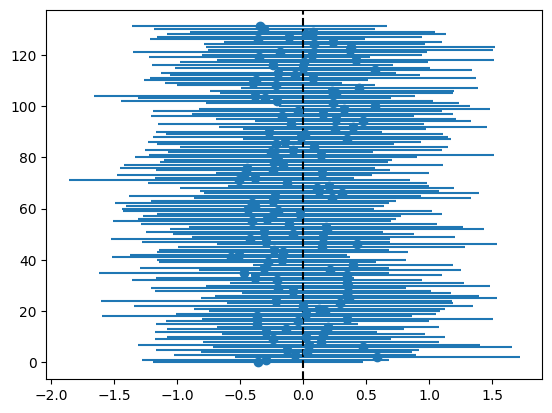

In [13]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)

betas_lower = beta_weights - z_norm * np.sqrt( np.diag(model_nesterov.weights_covariance) )
betas_upper = beta_weights + z_norm * np.sqrt( np.diag(model_nesterov.weights_covariance) )

lower_error = beta_weights - betas_lower
upper_error = betas_upper - beta_weights

xerr = np.vstack([lower_error, upper_error])

plt.errorbar(
    beta_weights,
    np.arange(beta_weights.shape[0]),
    xerr = xerr,
    fmt="o"
)
plt.axvline(0, linestyle = "dashed", color = "black")

plt.show()

Unfortunately, since the weights in the last layer of the model are exactly the parameters we are interested in, it is a registered problem in thetaflow that the use of more than 6 nodes in the last layer tend to produce a near singular hessian matrix, with corresponding very high values for its inverse, the matrix that approximates the covariance structure for those parameters. In classical statistical model applications, it is recommended to consider a small last layer in order to stabilize the convariance structure of the model, while also performing a fine-tune after convergence, where we only train that last layer and keep all the previous weights constant.

For this analysis we cannot determine and discuss exactly the significance of each hidden node to the model. However, that is not directly a limitation with our method, since no method in multidimensiona data analysis is able to determine that currently.

In [14]:
# Sort the hidden layer nodes with respect to their variances
node_variances = pd.DataFrame({"node": np.arange(contributions.shape[1]), "variance": np.var(contributions, ddof = 1, axis = 0)})
# node_variances = pd.DataFrame({"node": np.arange(hidden_activations.shape[1]), "variance": np.var(hidden_activations, ddof = 1, axis = 0)})
node_variances = node_variances.sort_values(by = "variance", ascending = False).reset_index(drop = True)

top_20_nodes_idx = node_variances.loc[:19, "node"].to_numpy()
print("Top variance nodes:", top_20_nodes_idx)

node_variances

Top variance nodes: [  2  41 114  71  42   6  35  94 100 107  60  73  46  76  48 118  55  62
 104  92]


,node,variance
0,2,3.291876e-01
1,41,2.926311e-01
2,114,2.483256e-01
3,71,2.419160e-01
4,42,2.356765e-01
...,...,...
127,19,3.263164e-04
128,89,8.292802e-05
129,117,3.244050e-05
130,115,1.649405e-05


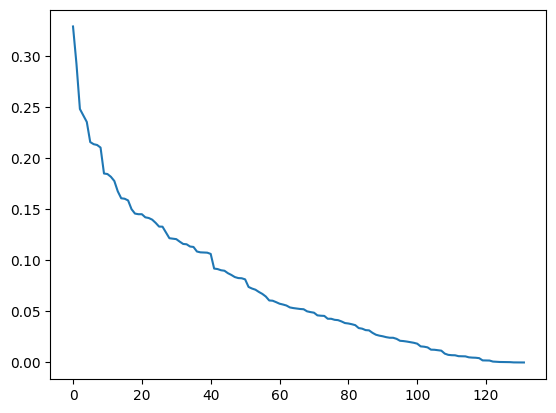

In [15]:
plt.plot(np.arange(node_variances.shape[0]), node_variances["variance"])
plt.show()

In [16]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib as mpl

In [243]:
tsne = TSNE(n_components = 2, perplexity = 30)
top_20_contributions_tsne = tsne.fit_transform( contributions[:,top_20_nodes_idx] )
top_20_contributions_tsne

tsne = TSNE(n_components = 2)
top_20_contributions_pca = tsne.fit_transform( contributions[:,top_20_nodes_idx] )
top_20_contributions_pca

array([[-19.12809   ,  24.878153  ],
       [  0.24693853,   0.73726946],
       [ 10.95278   ,   1.2652677 ],
       ...,
       [ 41.042767  , -37.20609   ],
       [-29.655516  ,  28.255098  ],
       [ 29.016949  , -39.1109    ]], dtype=float32)

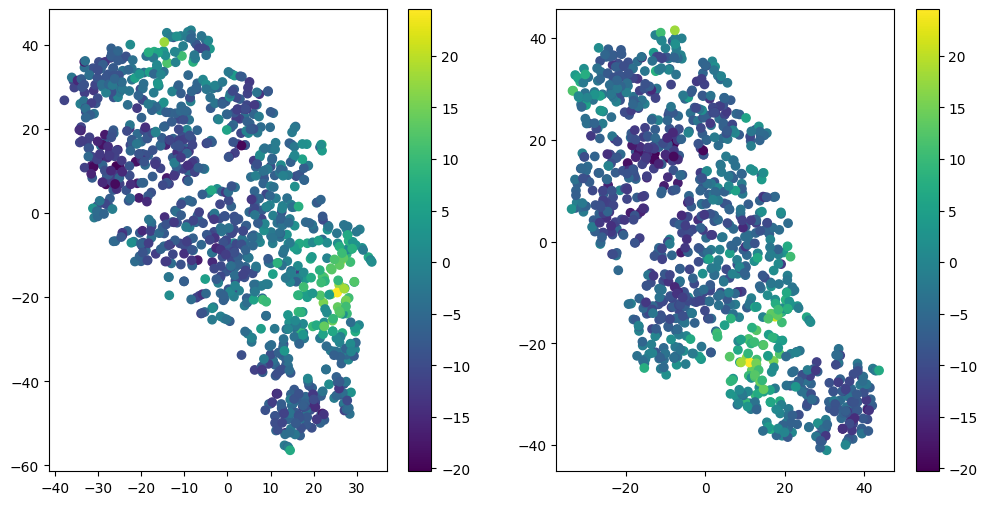

In [244]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

norm = mpl.colors.Normalize(
    vmin = np.min(theta_predictions),
    vmax = np.max(theta_predictions)
)
cmap = mpl.cm.viridis

sc = ax[0].scatter(
    top_20_contributions_tsne[:, 0],
    top_20_contributions_tsne[:, 1],
    c = theta_predictions,
    cmap = cmap,
    norm = norm
)

plt.colorbar(sc, ax = ax[0])

norm = mpl.colors.Normalize(
    vmin = np.min(theta_predictions),
    vmax = np.max(theta_predictions)
)
cmap = mpl.cm.viridis

sc = ax[1].scatter(
    top_20_contributions_pca[:, 0],
    top_20_contributions_pca[:, 1],
    c = theta_predictions,
    cmap = cmap,
    norm = norm
)

plt.colorbar(sc, ax = ax[1])
plt.show()

Unlike the cox-nnet application, the weights in thetaflow seem to be much more distributed in all nodes of the network, making it harder to simplify that information into lesser dimensions. However, both plots suggest a region with higher Prognostic-Indices (lighter colors) and a region with lower PI values (darker colors). That analysis is not enough to identify clear patterns given the small distance between all points and the non-linear surface structure in both plots, suggesting a classification of patients based on their genes must still be conducted in higher dimensions.

# Analysis of risk

Let us separate patients in two groups: high and low risk based on our classifications using $\theta$.

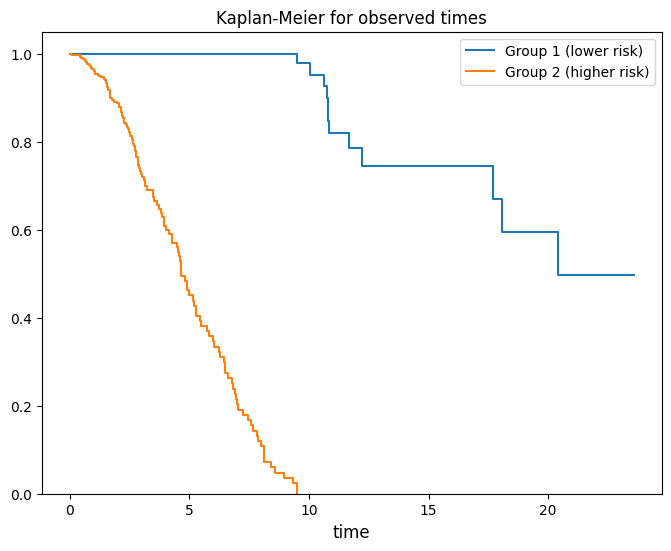

In [20]:
theta_predictions = model_nesterov.predict(X)["theta"].numpy().flatten()
group1_idx = np.where( theta_predictions <= np.median(theta_predictions) )[0]
group2_idx = np.where( theta_predictions > np.median(theta_predictions) )[0]

y1 = y[group1_idx]
delta1 = delta[group1_idx]
y2 = y[group2_idx]
delta2 = delta[group2_idx]

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(y1, delta1)
km.plot(ax = ax, ci_show = False, label = "Group 1 (lower risk)")

km = lifelines.KaplanMeierFitter()
km.fit(y2, delta2)
km.plot(ax = ax, ci_show = False, label = "Group 2 (higher risk)")

ax.set_ylim(0,1.05)
ax.set_title("Kaplan-Meier for observed times")
ax.set_xlabel("time", fontsize = 12)

plt.show()

As expected, it is clear that the model is able to discriminate patients risk profile. There is a clear distinction in patients. The first group identified by cox-nnet shows indeed a much lower propension for death than the second group of higher scores.

/tmp/ipykernel_15685/1192511663.py:37: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax1.scatter(
/tmp/ipykernel_15685/1192511663.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


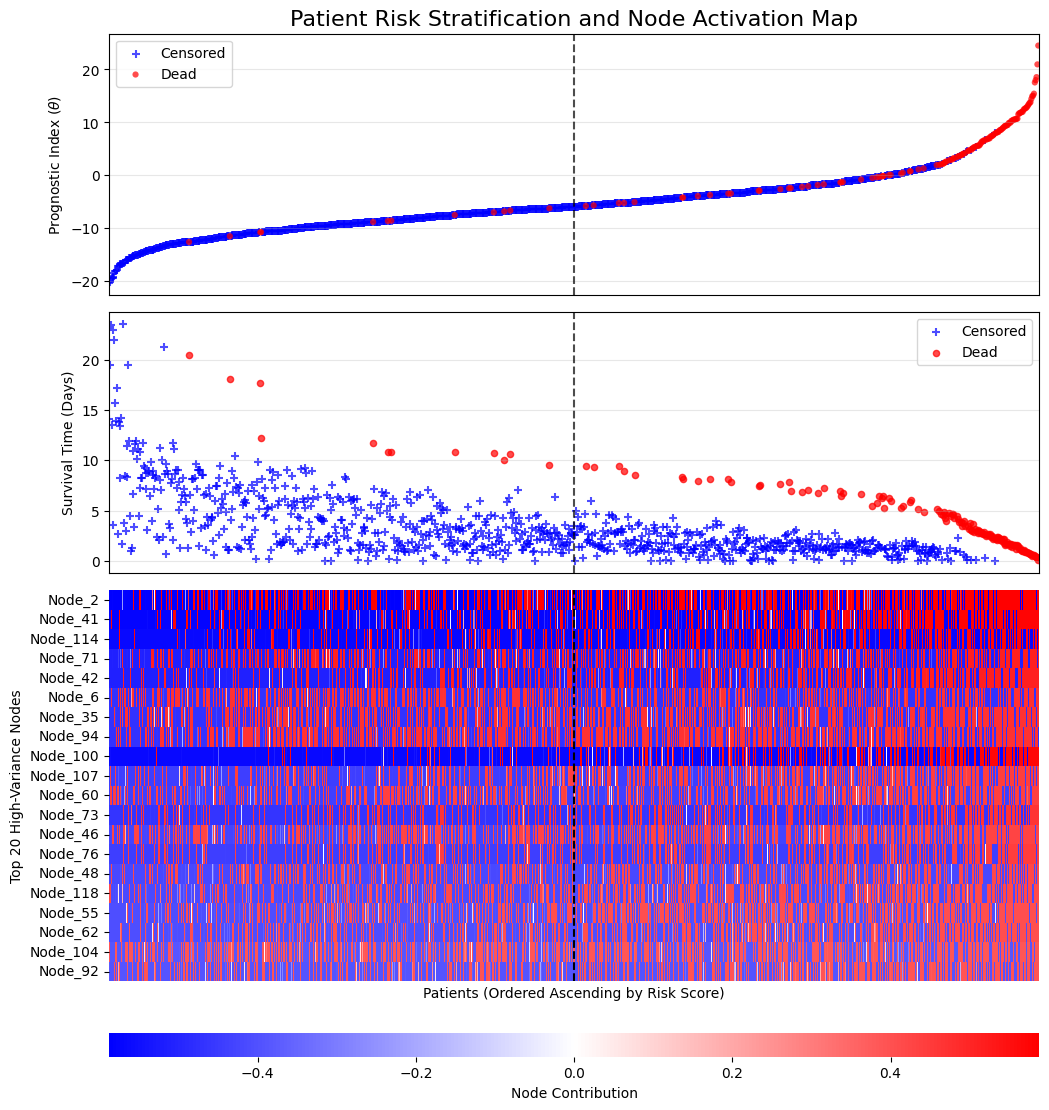

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Gather and Calculate Your Data ---
# (Assuming theta_predictions, y, delta, and contributions are already in memory)

# Calculate variance across columns (patients) to find the most discriminative nodes
node_variances = np.var(contributions, axis=0)
top_20_idx = np.argsort(node_variances)[::-1][:20]
top_contributions = contributions[:, top_20_idx]

# --- 2. Sort Everything by the Prognostic Index (Theta) ---
# This is the anchor for the entire plot
patient_sort_idx = np.argsort(theta_predictions)

sorted_theta = theta_predictions[patient_sort_idx]
sorted_y = y[patient_sort_idx].flatten()        # Survival times
sorted_delta = delta[patient_sort_idx].flatten() # Event status (1=Dead, 0=Censored)
sorted_top_contributions = top_contributions[patient_sort_idx, :]

# Find the median cutoff for the visual boundary
median_theta = np.median(sorted_theta)
median_idx = len(sorted_theta) // 2

# --- 3. Build the Figure Layout ---
fig, (ax1, ax2, ax3) = plt.subplots(
    nrows = 3, ncols = 1, 
    figsize = (12, 14), 
    sharex = True, # Locks the X-axis so patients align perfectly vertically
    gridspec_kw = {'height_ratios': [1, 1, 2], 'hspace': 0.05}
)

# --- PANEL 1: Risk Score Distribution ---
patients_idx = np.arange(len(sorted_theta))
ax1.scatter(
    patients_idx[sorted_delta == 0.0], sorted_theta[sorted_delta == 0.0], 
    # c = ['blue' if val < median_theta else 'red' for val in sorted_theta],
    c = 'blue',
    marker = '+',
    s = 30, edgecolors = 'none', alpha = 0.7,
    label = "Censored"
)
ax1.scatter(
    patients_idx[sorted_delta == 1.0], sorted_theta[sorted_delta == 1.0], 
    # c = ['blue' if val < median_theta else 'red' for val in sorted_theta],
    # c = ['blue' if d == 0 else 'red' for d in sorted_delta],
    c = 'red',
    marker = 'o',
    s = 20, edgecolors = 'none', alpha = 0.7,
    label = "Dead"
)
ax1.axvline(x = median_idx, color='k', linestyle='--', alpha=0.7)
ax1.set_ylabel("Prognostic Index ($\\theta$)")
ax1.set_title("Patient Risk Stratification and Node Activation Map", fontsize=16)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- PANEL 2: Clinical Survival Status ---
# Create masks to plot dead and censored patients with different markers/colors
dead_mask = sorted_delta == 1
censored_mask = sorted_delta == 0

ax2.scatter(
    np.where(censored_mask)[0], sorted_y[censored_mask], 
    color = 'blue', marker = '+', s = 30, label = 'Censored', alpha = 0.7
)
ax2.scatter(
    np.where(dead_mask)[0], sorted_y[dead_mask], 
    color = 'red', marker = 'o', s = 20, label = 'Dead', alpha = 0.7
)
ax2.axvline(x = median_idx, color='k', linestyle='--', alpha = 0.7)
ax2.set_ylabel("Survival Time (Days)")
ax2.legend(loc = 'upper right')
ax2.grid(True, alpha=0.3)

# --- PANEL 3: Top 20 Node Heatmap ---
# Transpose the matrix so Nodes are rows and Patients are columns
df_heatmap = pd.DataFrame(
    sorted_top_contributions.T,
    index=[f"Node_{i}" for i in top_20_idx]
)

sns.heatmap(
    df_heatmap, 
    cmap = "bwr", 
    center = 0, 
    ax = ax3,
    cbar_kws = {'label': 'Node Contribution', 'orientation': 'horizontal', 'pad': 0.1, 'aspect': 40},
    xticklabels = False # Hide the crowded patient indices
)
ax3.axvline(x = median_idx, color = 'k', linestyle = '--', alpha = 1.0)
ax3.set_xlabel("Patients (Ordered Ascending by Risk Score)")
ax3.set_ylabel("Top 20 High-Variance Nodes")

# Clean up and render
plt.tight_layout()
plt.show()

In [78]:
# W_input = model_nesterov.dense1.get_weights()[0]
# gene_names = np.array([gene_id_to_name[v] for v in X.columns])

# print("Extracting Gene Weights for the Top High-Variance Nodes...")

# # Loop through your top nodes and export their specific gene weights
# for rank, node_idx in enumerate(top_20_idx):
#     # Extract the specific column of weights for this node
#     node_weights = W_input[:, node_idx]
    
#     # Create a DataFrame matching the genes to their weights
#     df_node = pd.DataFrame({
#         'Gene': gene_names,
#         'Weight': node_weights
#     })
    
#     # Sort the genes from highest positive weight to lowest negative weight
#     # (GSEA tools strictly require the list to be ranked like this)
#     df_node_sorted = df_node.sort_values(by = 'Weight', ascending = False)
    
#     # Save to a CSV file
#     filename = f"NodeGeneWeightsData/NodeRank_{rank + 1}_NodeIdx_{node_idx}_KEGG_Input.csv"
#     df_node_sorted.to_csv(filename, index=False)
    
#     print(f"Exported {filename} (Top Gene: {df_node_sorted.iloc[0]['Gene']})")

Extracting Gene Weights for the Top High-Variance Nodes...
Exported NodeGeneWeightsData/NodeRank_1_NodeIdx_2_KEGG_Input.csv (Top Gene: CLEC3A)
Exported NodeGeneWeightsData/NodeRank_2_NodeIdx_41_KEGG_Input.csv (Top Gene: HMGCS2)
Exported NodeGeneWeightsData/NodeRank_3_NodeIdx_114_KEGG_Input.csv (Top Gene: CPB1)
Exported NodeGeneWeightsData/NodeRank_4_NodeIdx_71_KEGG_Input.csv (Top Gene: BMPR1B)
Exported NodeGeneWeightsData/NodeRank_5_NodeIdx_42_KEGG_Input.csv (Top Gene: JCHAIN)
Exported NodeGeneWeightsData/NodeRank_6_NodeIdx_6_KEGG_Input.csv (Top Gene: SLPI)
Exported NodeGeneWeightsData/NodeRank_7_NodeIdx_35_KEGG_Input.csv (Top Gene: STAC2)
Exported NodeGeneWeightsData/NodeRank_8_NodeIdx_94_KEGG_Input.csv (Top Gene: CLEC3A)
Exported NodeGeneWeightsData/NodeRank_9_NodeIdx_100_KEGG_Input.csv (Top Gene: VSTM2A)
Exported NodeGeneWeightsData/NodeRank_10_NodeIdx_107_KEGG_Input.csv (Top Gene: CLEC3A)
Exported NodeGeneWeightsData/NodeRank_11_NodeIdx_60_KEGG_Input.csv (Top Gene: NLRP2)
Exported 

As done in the original Cox-nnet paper, for each of the 17227 genes and each node from the encountered top 20, we obtain the correlation between these values for all patients in the dataset. Below, we build these correlations manually and plot their corresponding values accordingly.

Here, we take our leave to criticize the choice of the Pearson coefficient for this analysis. Since the activation values from the hidden layer are outputs from a tanh activation function, which, in our case is much more saturated than theirs for some reason, it is not reasonable to consider the Pearson linear correlation between the numerical positive variable of actual gene expression data obtained from the count matrix and a variable that only ranges from -1 to 1, as we will see in the next plot.

In [247]:
top_20_activations = hidden_activations[:, top_20_idx]
expression_matrix = X.to_numpy() # or however your matrix is stored

# Center the matrices
X_centered = X - np.mean(X, axis = 0)
A_centered = top_20_activations - np.mean(top_20_activations, axis = 0)

# Calculate sum of squares
X_ss = np.sum(X_centered**2, axis = 0)
A_ss = np.sum(A_centered**2, axis = 0)

# Calculate dot product and divide by sqrt of sum of squares
correlations = np.dot(X_centered.T, A_centered) / np.sqrt(np.outer(X_ss, A_ss))

# gene_names should be a list of your 19,500 protein-coding genes
df_correlations = pd.DataFrame(
    correlations, 
    index = gene_names, 
    columns=[f"Node_{i}_Corr" for i in top_20_idx]
)

df_correlations

,Node_2_Corr,Node_41_Corr,Node_114_Corr,Node_71_Corr,Node_42_Corr,Node_6_Corr,Node_35_Corr,Node_94_Corr,Node_100_Corr,Node_107_Corr,Node_60_Corr,Node_73_Corr,Node_46_Corr,Node_76_Corr,Node_48_Corr,Node_118_Corr,Node_55_Corr,Node_62_Corr,Node_104_Corr,Node_92_Corr
TSPAN6,0.022535,0.014065,-0.186102,-0.068390,-0.248262,0.184408,-0.042920,-0.096627,0.002357,-0.139957,0.192868,-0.178249,0.039265,-0.181064,-0.048278,-0.156985,-0.076076,-0.147484,-0.002615,-0.232424
TNMD,0.228387,0.083256,0.030614,-0.294228,0.039041,0.237417,-0.128091,0.255822,-0.054315,-0.093956,0.225198,0.102309,-0.208345,0.094282,-0.123070,-0.133519,-0.034796,-0.170610,-0.158033,-0.042349
DPM1,-0.020140,-0.015758,0.015920,0.210431,-0.199172,-0.117934,0.260387,-0.271327,-0.079045,0.100854,0.080147,-0.320544,0.356031,-0.300090,0.137284,0.007969,-0.066092,0.173195,0.232308,0.000908
SCYL3,-0.151037,0.065128,-0.077911,-0.009742,0.081742,-0.181333,-0.210644,0.004164,0.041365,0.050733,-0.260003,0.284134,-0.223289,0.210700,0.234906,-0.196710,0.027974,-0.141865,-0.346504,0.239608
C1orf112,-0.216977,0.047936,-0.193934,0.094281,-0.284947,-0.140647,0.049151,-0.451622,0.034637,0.142034,0.032025,-0.373003,0.228513,-0.385950,0.340949,-0.230954,-0.214153,0.210960,-0.013279,0.007320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DUS4L-BCAP29,-0.055719,0.062756,0.122447,0.020173,-0.017822,0.038381,0.047941,0.090353,-0.008930,0.074677,0.001310,0.096115,-0.028376,0.063697,0.072091,-0.022478,0.059233,-0.057050,-0.034285,0.092729
NPBWR1,-0.006053,-0.029355,-0.065210,-0.046465,-0.187529,0.075568,0.069843,-0.092360,0.052554,0.040348,0.161041,-0.234389,0.046032,-0.231646,0.024611,-0.023386,-0.169229,0.131276,0.102080,-0.104683
AC010980.1,0.041853,0.029799,-0.042711,0.015488,-0.189741,0.184760,0.072839,-0.098987,-0.003430,-0.035750,0.194085,-0.252323,0.125228,-0.291086,0.033283,-0.005827,-0.078198,0.009760,0.140394,-0.108004
AL391628.1,0.029874,-0.115841,-0.003266,-0.073683,-0.053867,0.280351,0.019008,-0.006140,0.062341,-0.178872,-0.035280,0.024685,-0.015205,0.027067,-0.227744,-0.291923,-0.042715,-0.010129,-0.111916,-0.006748


Fixing Node_2_Corr
Gene with greatest negative correlation to Node_2_Corr: EFCAB7 (corr: -0.4374)
Gene with greatest positive correlation to Node_2_Corr: VAMP5 (corr: 0.5388)


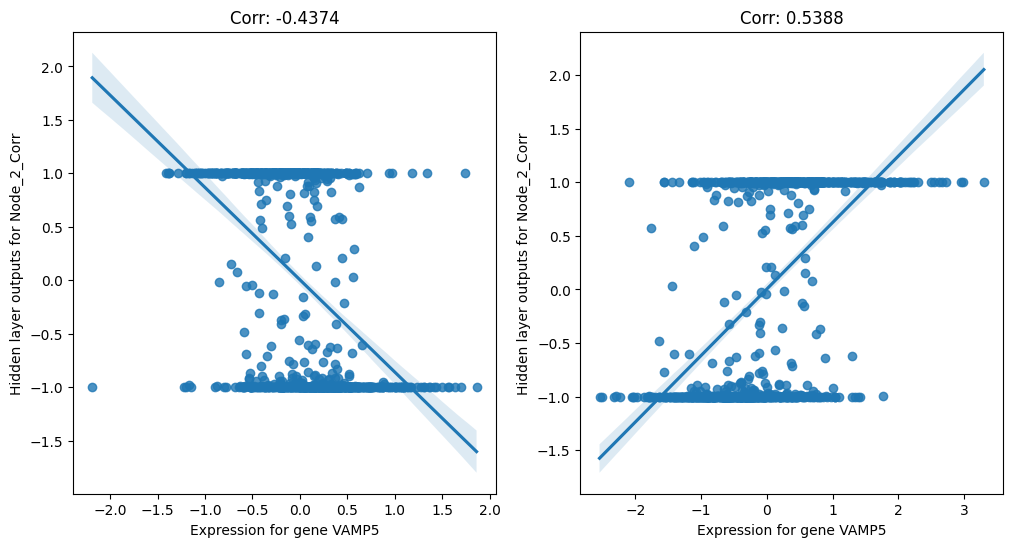

In [251]:
top_node_i = 0
top_node_name = df_correlations.columns[top_node_i]

lowest_correlation_gene_node_i = np.argmin(correlations, axis = 0)[top_node_i]
lowest_gene_name = gene_names[lowest_correlation_gene_node_i]

highest_correlation_gene_node_i = np.argmax(correlations, axis = 0)[top_node_i]
highest_gene_name = gene_names[highest_correlation_gene_node_2]

print("Fixing {}".format(top_node_name))
print("Gene with greatest negative correlation to {}: {} (corr: {:.4f})".format( top_node_name, lowest_gene_name, correlations[lowest_correlation_gene_node_i,0] ))
print("Gene with greatest positive correlation to {}: {} (corr: {:.4f})".format( top_node_name, highest_gene_name, correlations[highest_correlation_gene_node_i,0] ))

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

X_lowest_gene = X.iloc[:,lowest_correlation_gene_node_i].to_numpy().flatten()
X_highest_gene = X.iloc[:,highest_correlation_gene_node_i].to_numpy().flatten()

# sns.scatterplot(x = X_lowest_gene, y = top_20_activations[:,top_node_i], ax = ax[0])
sns.regplot(x = X_lowest_gene, y = top_20_activations[:,top_node_i], ax = ax[0])
ax[0].set_title("Corr: {:.4f}".format(np.corrcoef(X_lowest_gene, top_20_activations[:,top_node_i])[0,1]))
ax[0].set_xlabel("Expression for gene {}".format(highest_gene_name))
ax[0].set_ylabel("Hidden layer outputs for {}".format(top_node_name))

# sns.scatterplot(x = X_highest_gene, y = top_20_activations[:,top_node_i], ax = ax[1])
sns.regplot(x = X_highest_gene, y = top_20_activations[:,top_node_i], ax = ax[1])
ax[1].set_title("Corr: {:.4f}".format(np.corrcoef(X_highest_gene, top_20_activations[:,top_node_i])[0,1]))
ax[1].set_xlabel("Expression for gene {}".format(highest_gene_name))
ax[1].set_ylabel("Hidden layer outputs for {}".format(top_node_name))

plt.show()

As the plot suggest, Pearson correlation may not be the optimal metric. Essentially, we are making an analogous evaluation than modeling data on the unit interval (rescaled to $(-1,1)$) as a linear regression instead of considering a beta regression for example.

In order for us to remove this strictly linear association measuring, we consider the Spearman correlation coefficient instead.

In [252]:
from scipy.stats import rankdata

In [162]:
top_20_activations = hidden_activations[:, top_20_idx]
expression_matrix = X.to_numpy() # or however your matrix is stored

X_ranks = rankdata(X, axis=0)

# Center the matrices
X_centered = X - np.mean(X, axis = 0)
A_centered = top_20_activations - np.mean(top_20_activations, axis = 0)

# Calculate sum of squares
X_ss = np.sum(X_centered**2, axis = 0)
A_ss = np.sum(A_centered**2, axis = 0)

# Calculate dot product and divide by sqrt of sum of squares
correlations = np.dot(X_centered.T, A_centered) / np.sqrt(np.outer(X_ss, A_ss))

# gene_names should be a list of your 19,500 protein-coding genes
df_correlations = pd.DataFrame(
    correlations, 
    index = gene_names, 
    columns=[f"Node_{i}_Corr" for i in top_20_idx]
)

df_correlations

array([0.53879767, 0.34141259, 0.4066278 , 0.46389408, 0.51367172,
       0.61534633, 0.50334373, 0.55973613, 0.27278243, 0.49908594,
       0.50531445, 0.7244015 , 0.59211281, 0.73087436, 0.59442257,
       0.3510316 , 0.52612318, 0.38497676, 0.52488421, 0.51328366])

<Axes: ylabel='Count'>

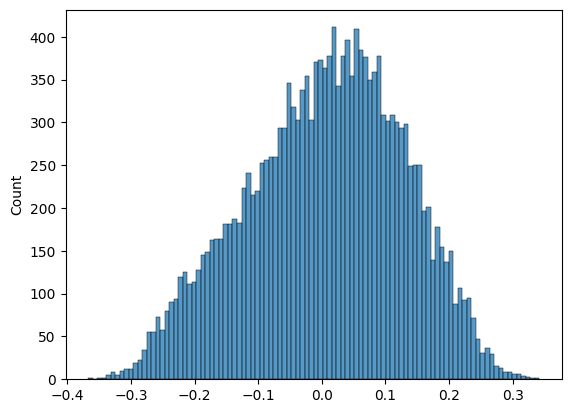

In [155]:
sns.histplot(correlations[:,1], bins = 100)